# TP Unidad VII: Representaciones tiempo-frecuencia

En esta notebook implementamos los ejercicios de la guía de la Unidad VII, con especial énfasis en la transformada diádica de wavelets y en el análisis comparativo de escalogramas con los espectrogramas.
Se realiza también un acercamiento a la compresión con pérdida basada en wavelets.



## Transformada Wavelet Diádica

En el caso continuo, la transformada wavelet se define como:

$$W_x(a,b) = \frac{1}{\sqrt{|a|}} \int_{-\infty}^{\infty} x(t) \psi^*\left(\frac{t-b}{a}\right) dt$$

La transformada wavelets diádica es un caso discreto de análisis multiescala que divide la señal en subbandas de baja y alta frecuencia usando escalas $a=2^j$. Para una ondita general $\psi(t)$, la familia diádica se define como:

$$\psi_{j,k}(t) = 2^{-j/2} \psi\left(\frac{t-k2^j}{2^j}\right),$$

Esto lleva a una forma discreta de coeficientes que permite el análisis multiescala con niveles $j$ y traslaciones $k$.

Los coeficientes de wavelet se obtienen como:

$$W_x[j,k] = \langle x, \psi_{j,k}\rangle = \int_{-\infty}^{\infty} x(t) \psi^*_{j,k}(t) \, dt.$$

En una implementación discreta con filtros de análisis, los coeficientes se pueden escribir como:

$$c_{j+1}[k] = \sum_n h[n-2k] \; c_j[n],$$
$$d_{j+1}[k] = \sum_n g[n-2k] \; c_j[n],$$

donde $h[n]$ es el filtro de aproximación y $g[n]$ el filtro de detalle de la ondita empleada, y se inicializa con $c_0[n]=x[n]$. 

La reconstrucción a partir de los coeficientes se realiza con los filtros de síntesis correspondientes:

$$\tilde x[n] = \sum_k \tilde h[n-2k] \; c_{j+1}[k] + \sum_k \tilde g[n-2k] \; d_{j+1}[k],$$

donde $\tilde h[n]$ y $\tilde g[n]$ pueden ser los filtros inversos asociados a la ondita.



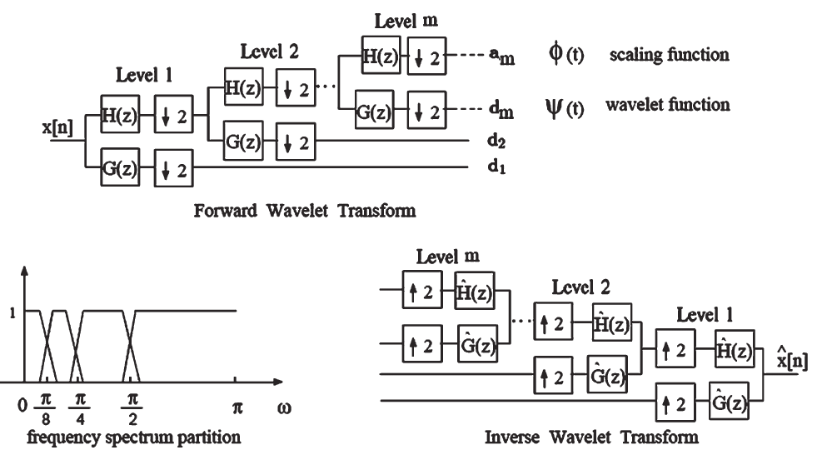

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, log2, sqrt

plt.rcParams['figure.figsize'] = (10, 5)

## Ejercicio 1

In [130]:
def dwt_single_level(x, h, g):
    x = np.asarray(x, dtype=float)
    n = len(x)
    L = len(h)
    parity = n % 2
    pad = max(L - 2 + parity, 0)
    x_pad = np.pad(x, (pad, pad), mode='symmetric')
    
    conv_lo = np.convolve(x_pad, h, mode='valid')
    conv_hi = np.convolve(x_pad, g, mode='valid')

    # downsampling
    lo = conv_lo[parity::2]
    hi = conv_hi[parity::2]
    return lo, hi


def dyadic_dwt(x, wavelet='haar', levels=None):
    wavelet_filters = {
        'haar': (
            np.array([1.0, 1.0]) / sqrt(2.0),
            np.array([1.0, -1.0]) / sqrt(2.0),
        ),
        'db2': (
            np.array([0.4829629131445341,
                      0.8365163037378079,
                      0.2241438680420134,
                     -0.1294095225512603]),
            np.array([-0.1294095225512603,
                     -0.2241438680420134,
                      0.8365163037378079,
                     -0.4829629131445341]),
        ),
        'db4': (
            np.array([0.2303778133088964,
                      0.7148465705529154,
                      0.6308807679295904,
                     -0.0279837694168599,
                     -0.1870348117190931,
                      0.0308413818359869,
                      0.0328830116668852,
                     -0.0105974017850021]),
            np.array([-0.0105974017850021,
                     -0.0328830116668852,
                      0.0308413818359869,
                      0.1870348117190931,
                     -0.0279837694168599,
                     -0.6308807679295904,
                      0.7148465705529154,
                     -0.2303778133088964]),
        ),
    }

    if wavelet not in wavelet_filters:
        raise ValueError(f'Wavelet desconocida: {wavelet}')

    h, g = wavelet_filters[wavelet]
    x = np.asarray(x, dtype=float)
    orig_len = len(x)
    if orig_len == 0:
        return [], np.array([]), 0

    max_levels = int(log2(orig_len / (len(h) - 1))) if orig_len >= len(h) else 0
    if levels is None:
        levels = max_levels
    else:
        levels = min(levels, max_levels)

    details = []
    a = x.copy()
    for _ in range(levels):
        if len(a) < len(h):
            break
        a, d = dwt_single_level(a, h, g)
        details.append(d)

    approx = a
    return details, approx, orig_len, levels


def scalogram_from_dwt(details, approx=None, original_length=None, use_energy=True):
    details_full = list(details)
    if approx is not None:
        details_full.append(approx)

    levels = len(details_full)
    if levels == 0:
        return np.zeros((0, 0))

    if original_length is None:
        original_length = len(details[0]) * 2
    N = original_length

    mat = np.zeros((levels, N))
    for i, c in enumerate(details_full):
        if use_energy:
            coeffs = np.abs(c) ** 2
        else:
            coeffs = np.abs(c)
        M = len(coeffs)
        repeat = int(N // M)
        if repeat <= 0:
            up = np.interp(np.linspace(0, M - 1, N), np.arange(M), coeffs)
        else:
            up = np.repeat(coeffs, repeat)
            if up.size < N:
                up = np.pad(up, (0, N - up.size), mode='edge')
            elif up.size > N:
                up = up[:N]
        mat[i, :] = up
    return mat


def plot_scalogram(details, approx=None, levels=None, original_length=None, t=None, cmap='magma', use_energy=True):
    if levels is None:
        levels = len(details) # + (1 if approx is not None else 0)
    if original_length is None:
        original_length = len(details[0]) * 2
    if t is None:
        t = np.arange(original_length)
    mat = scalogram_from_dwt(details, approx=approx, original_length=original_length, use_energy=use_energy)
    img = mat[::-1, :]
    if approx is None:
        extent = [t[0], t[-1], 1, levels+1]
    else:
        extent = [t[0], t[-1], 1, levels+2]
    plt.imshow(img, aspect='auto', extent=extent, cmap=cmap, origin='lower', norm=LogNorm())
    plt.colorbar(label='Energía' if use_energy else '|coeficientes|')
    plt.xlabel('Tiempo')
    plt.ylabel('Nivel (diádico)')
    
    if approx is None:
        plt.yticks(range(1, levels+1, 1), ['D'+str(i) for i in range(levels, 0, -1)])
        plt.ylim(1, levels + 1)
    else:
        plt.yticks(range(1, levels+2, 1), ['A'+str(levels)] + ['D'+str(i) for i in range(levels, 0, -1)])
        plt.ylim(1, levels + 2)        

    plt.title('Escalograma (DWT diádica)')    
    plt.tight_layout()
    plt.show()


    
    
    
    



## Ejercicio 2

Frecuencia de muestreo: 48000 Hz, muestras: 28800


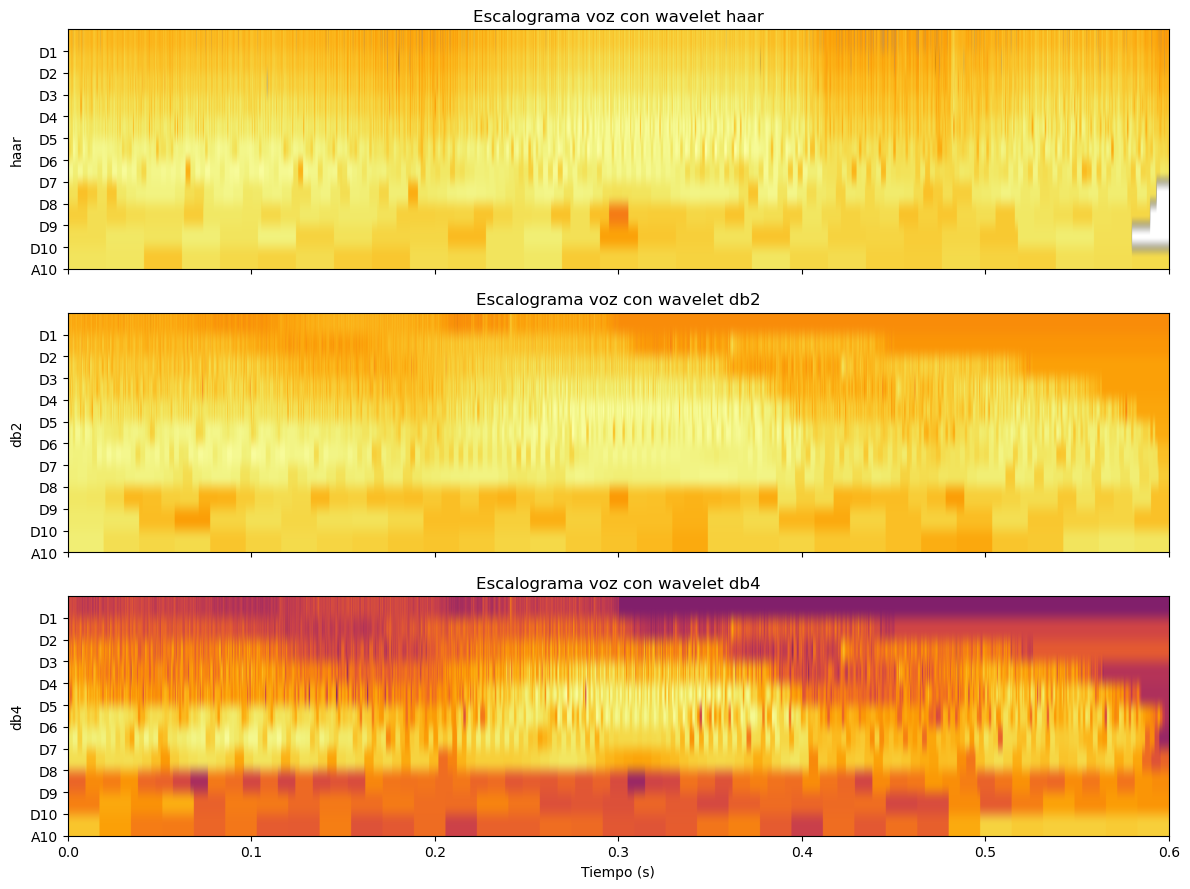

In [138]:
import wave
from matplotlib.colors import LogNorm

def load_wav_mono(path):
    with wave.open(path, 'rb') as wf:
        sr = wf.getframerate()
        n_frames = wf.getnframes()
        n_channels = wf.getnchannels()
        sampwidth = wf.getsampwidth()
        raw = wf.readframes(n_frames)

    dtype = {1: np.int8, 2: np.int16, 4: np.int32}.get(sampwidth)
    if dtype is None:
        raise ValueError(f'Formato de sample width no soportado: {sampwidth}')

    data = np.frombuffer(raw, dtype=dtype)
    if n_channels > 1:
        data = data.reshape(-1, n_channels).mean(axis=1)
    data = data.astype(float) / np.iinfo(dtype).max
    return sr, data


path = 'mic_F01_sa2.wav'
fs, x_voice = load_wav_mono(path)
x_voice = x_voice[int(fs * 4.8):int(fs * 5.4)]
print(f'Frecuencia de muestreo: {fs} Hz, muestras: {len(x_voice)}')

wavelets = ['haar', 'db2', 'db4']
levels = 10

fig, axes = plt.subplots(len(wavelets), 1, figsize=(12, 9), sharex=True)


for ax, name in zip(axes, wavelets):
    details, approx, orig_len, lvls = dyadic_dwt(x_voice, wavelet=name, levels=levels)  
    mat = scalogram_from_dwt(details, approx=approx, original_length=orig_len, use_energy=True)
    img = mat[::-1, :]
    extent = [0, len(x_voice) / fs, 1, lvls + 2]
    ax.imshow(img, aspect='auto', extent=extent, cmap='inferno', origin='lower', norm=LogNorm()) 
    ax.set_ylabel(f'{name}')
    ax.set_yticks(range(1, lvls+2, 1))
    ax.set_yticklabels(['A'+str(lvls)] + ['D'+str(i) for i in range(lvls, 0, -1)])
    ax.set_title(f'Escalograma voz con wavelet {name}')
    ax.set_ylim(1, lvls + 2)

axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()


## Ejercicio 3

Chirp: 10000 muestras, orig_len padded: 10000, niveles DWT: 11


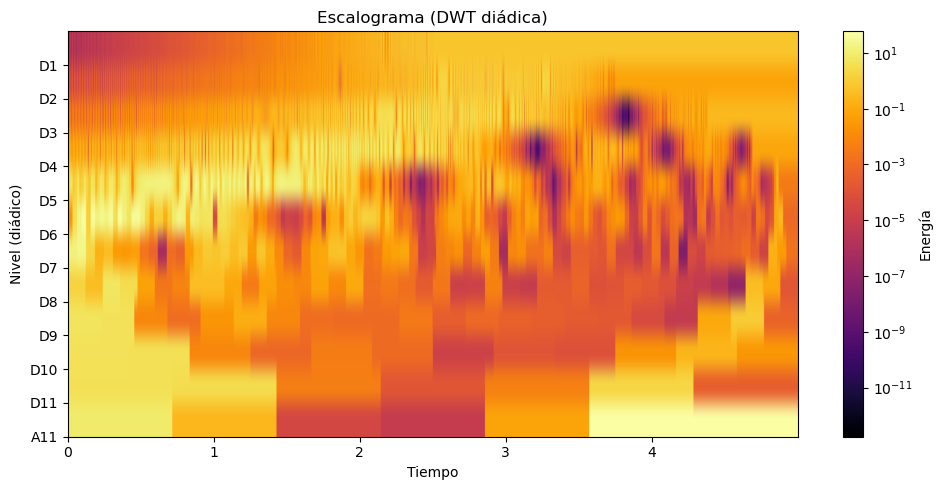

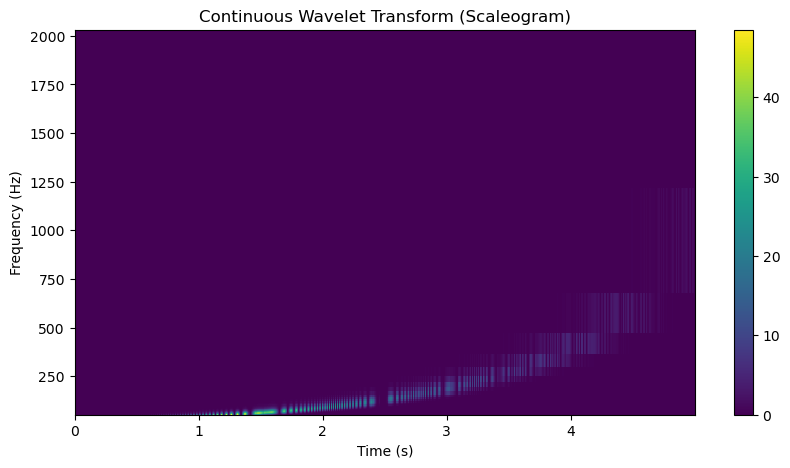

In [139]:
# Señal chirp exponencial + comparación DWT (db2) y CWT (PyWavelets)
# Genera una chirp con frecuencia instantánea que crece exponencialmente

import pywt

fs = 2000
T = 5.0
t = np.arange(0, T, 1 / fs)
f0, f1 = 20, 800
beta = np.log(f1 / f0) / T
f_inst = f0 * np.exp(beta * t)
phase = 2 * np.pi * f0 * (np.exp(beta * t) - 1) / beta
x = np.sin(phase)

# DWT diádica usando db2 
levels = 16
details_chirp, approx_chirp, orig_len_chirp, levels = dyadic_dwt(x, wavelet='db2', levels=levels)
print(f'Chirp: {len(x)} muestras, orig_len padded: {orig_len_chirp}, niveles DWT: {len(details_chirp)}')

# Graficar escalograma DWT 
plot_scalogram(details_chirp, approx=approx_chirp, levels=levels, original_length=orig_len_chirp, t=t, cmap='inferno')

# CWT muestreada usando PyWavelets

scales = np.arange(1, 32)
coeffs, freqs = pywt.cwt(x, scales, 'morl', sampling_period=1.0 / fs)
power = np.abs(coeffs)**2

plt.figure(figsize=(10, 5))

pcm = plt.pcolormesh(t, freqs, power)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Continuous Wavelet Transform (Scaleogram)")
plt.colorbar(pcm, ax=plt.gca())
plt.show()

## Ejercicio 4

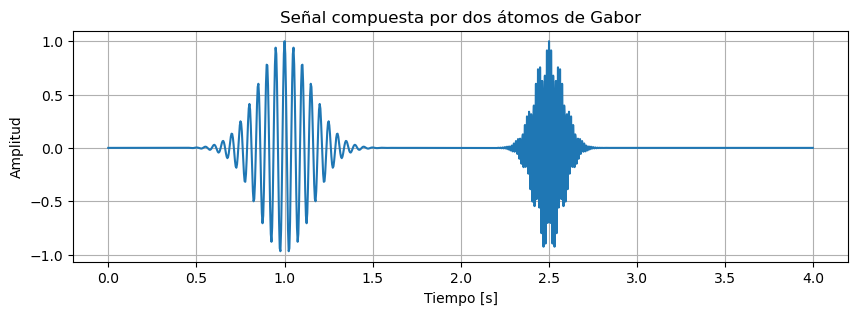

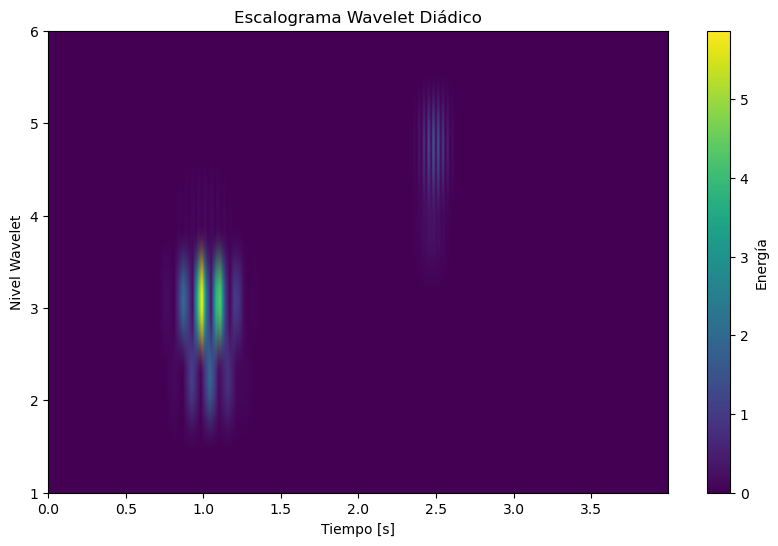

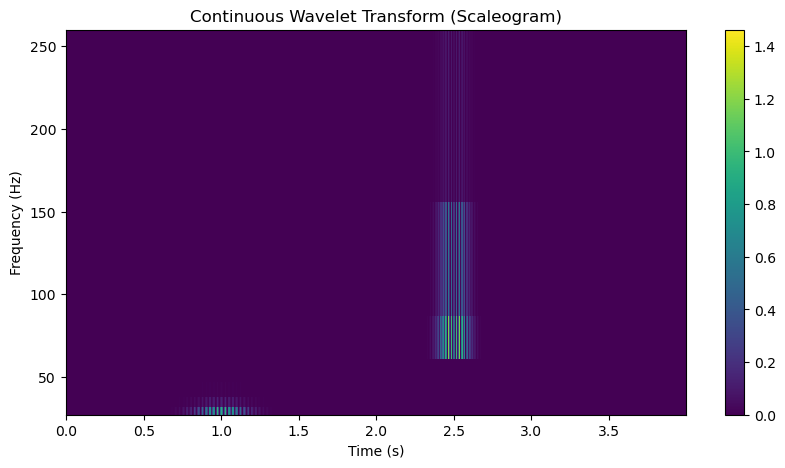

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# =====================================================
# Generación de la señal
# =====================================================

Fs = 256

t = np.arange(0, 4, 1/Fs)

# Átomo de Gabor 1 (20 Hz)
g1 = np.exp(-(t - 1)**2 / (2 * 0.15**2))
g1 = g1 * np.cos(2 * np.pi * 20 * t)

# Átomo de Gabor 2 (80 Hz)
g2 = np.exp(-(t - 2.5)**2 / (2 * 0.08**2))
g2 = g2 * np.cos(2 * np.pi * 80 * t)

x = g1 + g2

# =====================================================
# Gráfico de la señal
# =====================================================

plt.figure(figsize=(10,3))
plt.plot(t, x)
plt.title("Señal compuesta por dos átomos de Gabor")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

# =====================================================
# Transformada Wavelet Diádica
# =====================================================

wavelet = 'db4'
level = 5

coeffs = pywt.wavedec(
    x,
    wavelet,
    level=level
)

# =====================================================
# Construcción del escalograma
# =====================================================

scalogram = []

# Detalles
for j in range(1, level + 1):

    D = np.abs(coeffs[j])**2

    old_idx = np.linspace(0, 1, len(D))
    new_idx = np.linspace(0, 1, len(x))

    D_interp = np.interp(
        new_idx,
        old_idx,
        D
    )

    scalogram.append(D_interp)

# Aproximación final
A = np.abs(coeffs[0])**2

old_idx = np.linspace(0, 1, len(A))
new_idx = np.linspace(0, 1, len(x))

A_interp = np.interp(
    new_idx,
    old_idx,
    A
)

scalogram.append(A_interp)

# Conversión a matriz
scalogram = np.array(scalogram)

# =====================================================
# Gráfico del escalograma
# =====================================================

plt.figure(figsize=(10,6))

plt.imshow(
    scalogram,
    aspect='auto',
    origin='lower',
    extent=[0, t[-1], 1, level+1]
)

plt.colorbar(label='Energía')

plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel Wavelet')

# plt.yticks(
#     np.arange(1, level+2),
#     ['D1','D2','D3','D4','D5','A5']
# )

plt.title('Escalograma Wavelet Diádico')

plt.show()

# CWT muestreada usando PyWavelets

scales = np.arange(1, 8)
coeffs, freqs = pywt.cwt(x, scales, 'morl', sampling_period=1.0 / Fs)
power = np.abs(coeffs)**2

plt.figure(figsize=(10, 5))

pcm = plt.pcolormesh(t, freqs, power)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Continuous Wavelet Transform (Scaleogram)")
plt.colorbar(pcm, ax=plt.gca())
plt.show()

## Ejercicio 5

### Denoising usando pywavelets

/home/leandro/.local/lib/python3.14/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 6 is too high: all coefficients will experience boundary effects.
  warnings.warn(


Sigma estimado: 0.6875757004407003
Threshold: 0.7666996132446025
RMSE señal ruidosa : 0.6916491066166814
RMSE señal filtrada: 0.4398110780483869


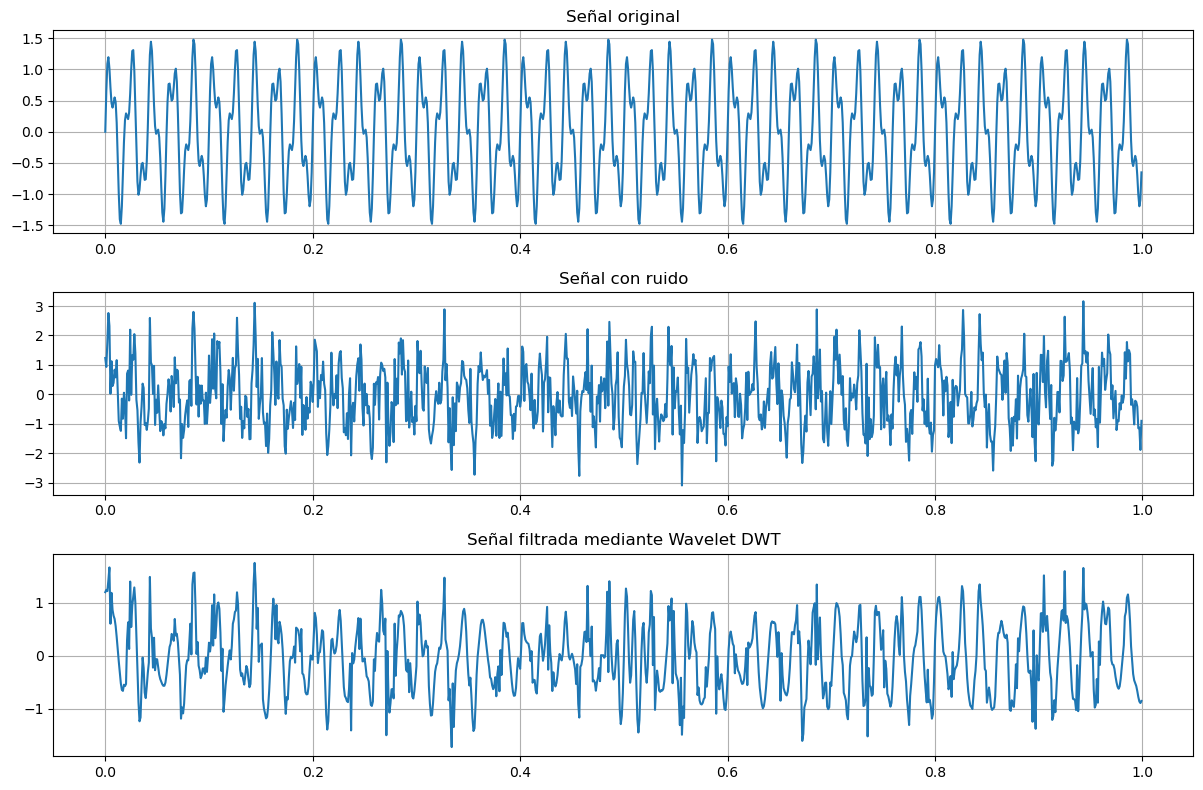

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# =====================================================
# Señal sintética
# =====================================================

Fs = 1000

t = np.arange(0, 1, 1/Fs)

x = (
    np.sin(2*np.pi*50*t)
    + 0.5*np.sin(2*np.pi*120*t)
)

# =====================================================
# Agregado de ruido
# =====================================================

np.random.seed(0)

sigma_noise = 0.7

x_noisy = x + sigma_noise*np.random.randn(len(x))

# =====================================================
# DWT
# =====================================================

# wavelet = 'db4'
# wavelet = 'sym8'
wavelet = 'coif5'
level = 6

coeffs = pywt.wavedec(
    x_noisy,
    wavelet,
    level=level
)

# =====================================================
# Estimación del ruido
# =====================================================

# Detalle de mayor frecuencia (D1)
sigma_est = np.median(
    np.abs(coeffs[-1])
) / 0.6745

# Umbral universal de Donoho
threshold = 0.3*sigma_est*np.sqrt(2*np.log(len(x_noisy)))

print("Sigma estimado:", sigma_est)
print("Threshold:", threshold)

# =====================================================
# Thresholding
# =====================================================

coeffs_denoised = [coeffs[0]]

for D in coeffs[1:]:

    D_thr = pywt.threshold(
        D,
        threshold,
        mode='soft'
    )

    coeffs_denoised.append(D_thr)

# =====================================================
# Reconstrucción
# =====================================================

x_denoised = pywt.waverec(
    coeffs_denoised,
    wavelet
)

# waverec puede devolver 1 muestra extra
x_denoised = x_denoised[:len(x)]

# =====================================================
# Cálculo de errores
# =====================================================

rmse_noisy = np.sqrt(
    np.mean((x - x_noisy)**2)
)

rmse_denoised = np.sqrt(
    np.mean((x - x_denoised)**2)
)

print("RMSE señal ruidosa :", rmse_noisy)
print("RMSE señal filtrada:", rmse_denoised)

# =====================================================
# Gráficos
# =====================================================

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(t,x)
plt.title('Señal original')
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(t,x_noisy)
plt.title('Señal con ruido')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(t,x_denoised)
plt.title('Señal filtrada mediante Wavelet DWT')
plt.grid(True)

plt.tight_layout()
plt.show()